# DOT PY — Data Science & AI Program
## Module 01 · Data Preprocessing
### In-Class Task Session — Titanic Dataset (Student Template)

---

**BY:** Mohamed Walid  
**Cohort:** DSA-2026  
**Dataset:** Titanic (kaggle.com/competitions/titanic)  
**Objective:** Apply a full data preprocessing and visualization pipeline on a real dataset

---

> **How to use this notebook:**  
> Read the markdown explanation for each section *before* writing your code.  
> Each code cell contains a `TODO` comment with hints — write the code yourself in that cell.  
> Do not just copy a solution — understand *why* each step is needed before you write it.


---

## Business Brief — Why Are We Preprocessing This Data?

### The Problem

In April 1912, the RMS Titanic sank after hitting an iceberg.  
1,502 out of 2,224 passengers and crew died.

The Titanic dataset gives us information about 891 of those passengers —  
their age, gender, ticket class, fare paid, and whether they survived.

**The business question is:**  
> *Can we build a model that predicts whether a passenger would have survived,  
> based on the information available at the time of boarding?*

This type of problem is called **binary classification** — the output is either 0 (did not survive) or 1 (survived).

---

### Why Does This Matter Beyond the Titanic?

The Titanic is a teaching dataset, but the skills you practice here apply directly to real business problems:


| Titanic Problem | Real Business Equivalent |
|----------------|--------------------------|
| Predict survival based on passenger profile | Predict customer churn based on user behavior |
| Identify which features (Age, Class, Sex) drive survival | Identify which factors drive loan default |
| Handle missing Age values | Handle missing income or credit score fields |
| Encode Sex and Embarked as numbers | Encode product category or city as model input |
| Scale Fare and Age to the same range | Normalize transaction amount and account age |

The preprocessing steps you apply today are the **exact same steps** used in production data pipelines  
at banks, e-commerce platforms, and healthcare companies.

---

### What We Know About the Data Before We Start

From historical records and domain knowledge, we already know a few things:

- **Women and children were evacuated first** — so `Sex` and `Age` are likely strong predictors
- **First class passengers had better access to lifeboats** — so `Pclass` is likely important
- **Families may have stayed together** — so `SibSp` and `Parch` carry signal about group behavior
- **Cabin location determined proximity to lifeboats** — but `Cabin` has 77% missing values

This domain knowledge directly influences the preprocessing decisions we make:  
which columns to keep, which to drop, and which new features to engineer.

---

### What We Are NOT Doing in This Session

This session is about **preparing the data only**.  
We are not building a model yet.

Clean data in → better model out.  
Garbage data in → garbage model out — no matter how advanced the algorithm is.

> **Data preprocessing is not a formality before the real work.  
> It is the foundation that determines the ceiling of your model's performance.**

---


---
## 1. Import Libraries

We start by importing the tools we need.

| Library | Why we use it |
|---------|--------------|
| `pandas` | Load and manipulate the dataset as a DataFrame |
| `numpy` | Numerical operations and array handling |
| `matplotlib` | Base plotting library |
| `seaborn` | Statistical visualizations built on top of matplotlib |
| `sklearn` | Machine learning utilities — preprocessing tools |


In [1]:
# TODO: Import the libraries needed for this notebook
# Hint: pandas, numpy, matplotlib.pyplot, seaborn
# Hint: also import LabelEncoder, StandardScaler, MinMaxScaler from sklearn.preprocessing

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder , StandardScaler , MinMaxScaler
from sklearn.model_selection import train_test_split


---
## 2. Load the Dataset

We load the Titanic dataset directly from a public URL so there is no need to upload any file.

**About the dataset:**  
The Titanic dataset contains information about 891 passengers who were aboard the RMS Titanic.  
The target column is `Survived` — 0 means the passenger did not survive, 1 means they did.


In [2]:
# TODO: Load the Titanic dataset from the URL below into a DataFrame called df
# url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
# Hint: use pd.read_csv()
# Then print the shape and show the first few rows

df = pd.read_csv('/content/titanic.csv')
print(df.shape)
df.head()



(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


---
## 3. Data Understanding

Before we do anything, we need to *understand* what we have.  
This step answers three questions:

1. What columns exist and what type is each one?
2. How many rows and columns do we have?
3. Are there any missing values?

**Column descriptions:**

| Column | Type | Description |
|--------|------|-------------|
| PassengerId | int | Unique ID — not useful for modeling |
| Survived | int | Target variable — 0=No, 1=Yes |
| Pclass | int | Ticket class — 1=First, 2=Second, 3=Third |
| Name | string | Passenger name |
| Sex | string | Gender |
| Age | float | Age in years — has missing values |
| SibSp | int | Number of siblings or spouses aboard |
| Parch | int | Number of parents or children aboard |
| Ticket | string | Ticket number |
| Fare | float | Passenger fare |
| Cabin | string | Cabin number — has many missing values |
| Embarked | string | Port of embarkation — C=Cherbourg, Q=Queenstown, S=Southampton |


In [3]:
# TODO: Show basic info about the dataset
# Hint: use df.info() to see column types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
# TODO: Show statistical summary of numeric columns
# Hint: use df.describe()
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
# TODO: Check missing values per column — count and percentage
# Hint: df.isnull().sum()  and  (df.isnull().sum() / len(df) * 100)
# Build a small DataFrame showing both, then filter to only show columns with missing values

missing_counts = df.isnull().sum().to_frame(name='missing_count')
missing_percentage = (df.isnull().sum() / len(df) * 100).to_frame(name='missing_percentage')

mis_df = missing_counts.merge(missing_percentage, left_index=True, right_index=True)

# Filter to show only columns with missing values
mis_df = mis_df[mis_df['missing_count'] > 0]

display(mis_df)

,missing_count,missing_percentage
Age,177,19.865320
Cabin,687,77.104377
Embarked,2,0.224467


**Observations:**
- `Age` has ~20% missing values — we will impute using the median
- `Cabin` has ~77% missing values — too many to impute, we will drop this column
- `Embarked` has 2 missing values — we will fill with the most frequent value (mode)


---
## 4. Handle Missing Values

**Strategy per column:**

| Column | Missing % | Strategy | Reason |
|--------|-----------|----------|--------|
| `Age` | ~20% | Fill with **median** | Median is robust to outliers — Age has a right-skewed distribution |
| `Cabin` | ~77% | **Drop** the column | Too many missing values — imputation would introduce too much noise |
| `Embarked` | ~0.2% | Fill with **mode** | Only 2 values missing — safest to use the most frequent category |

> **Why median and not mean for Age?**  
> The mean is pulled by extreme values (outliers). The median is the middle value of the sorted data —  
> it is not affected by outliers, which makes it a more reliable central estimate.


In [6]:
# TODO: Handle the three missing-value columns
# 1) Fill 'Age' with its median
# 2) Fill 'Embarked' with its mode (most frequent value)
# 3) Drop the 'Cabin' column entirely (too many missing values)
# Hint: .fillna()  and  .drop(columns=[...])
# Then confirm there are no missing values left

df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df.drop(columns=['Cabin'], inplace=True)

df.isnull().sum()

/tmp/ipykernel_30159/2880969593.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_30159/2880969593.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


---
## 5. Handle Duplicate Records

Duplicate rows mean the same passenger appears more than once.  
This can distort model training because that passenger gets more "votes" than others.

> **Rule:** Always check before removing — understand why duplicates exist.


In [7]:
# TODO: Check how many duplicate rows exist in the dataset
# Hint: df.duplicated().sum()
df.duplicated().sum()

np.int64(0)

---
## 6. Detect and Treat Outliers

We use the **IQR Method** (Interquartile Range) to detect outliers.

**How IQR works:**
1. Calculate Q1 (25th percentile) and Q3 (75th percentile)
2. IQR = Q3 - Q1
3. Lower bound = Q1 - 1.5 × IQR
4. Upper bound = Q3 + 1.5 × IQR
5. Any value outside these bounds is considered an outlier

We check `Age` and `Fare` — the two most important numeric columns.

> **Note:** As visible in the box plots in the visualization section,  
> `Fare` has significant right-skew with extreme high values.  
> Passengers in First Class paid fares much higher than the median — these are real outliers we need to treat.


In [8]:
# TODO: Write a function detect_outliers_iqr(df, column) that:
# 1) Calculates Q1 and Q3
# 2) Calculates IQR = Q3 - Q1
# 3) Calculates lower bound = Q1 - 1.5*IQR and upper bound = Q3 + 1.5*IQR
# 4) Counts how many rows fall outside these bounds
# 5) Returns (lower, upper)
# Then call this function for 'Age' and 'Fare'

def detect_outliers_iqr(df, column):
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5*IQR
  upper_bound = Q3 + 1.5*IQR
  outlier_count = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()
  return (lower_bound, upper_bound), outlier_count

print(detect_outliers_iqr(df, 'Age'))
print(detect_outliers_iqr(df, 'Fare'))


((np.float64(2.5), np.float64(54.5)), np.int64(66))
((np.float64(-26.724), np.float64(65.6344)), np.int64(116))


**Treatment — Capping (Winsorization):**

We cap outliers to the boundary values instead of removing the rows entirely.  
Removing rows loses data. Capping keeps all rows but limits extreme values to the boundary.

> This is called **Winsorization** — named after statistician Charles P. Winsor.

**Why is `Fare` the main concern here?**  
Looking at the data, some passengers in First Class paid extremely high fares (up to 512).  
The median fare is around 14. This extreme skew would distort distance-based models  
like KNN or any model sensitive to feature scale.  
Capping brings these values back to a statistically reasonable upper boundary.


In [9]:
# TODO: Cap (Winsorize) outliers in Age and Fare using the bounds you calculated
# Hint: use .clip(lower=..., upper=...)
# Print Fare stats BEFORE and AFTER capping to confirm the change

df['Age'].clip(lower=detect_outliers_iqr(df, 'Age')[0][0], upper=detect_outliers_iqr(df, 'Age')[0][1], inplace=True)
df['Fare'].clip(lower=detect_outliers_iqr(df, 'Fare')[0][0], upper=detect_outliers_iqr(df, 'Fare')[0][1], inplace=True)

print(df['Fare'].describe())



count    891.000000
mean      24.046813
std       20.481625
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max       65.634400
Name: Fare, dtype: float64


/tmp/ipykernel_30159/1709741201.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].clip(lower=detect_outliers_iqr(df, 'Age')[0][0], upper=detect_outliers_iqr(df, 'Age')[0][1], inplace=True)
/tmp/ipykernel_30159/1709741201.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

---
## 7. Drop Unnecessary Columns

Some columns carry no useful signal for a predictive model:

| Column | Reason to Drop |
|--------|---------------|
| `PassengerId` | Just an index — no predictive value |
| `Name` | Free text — too specific, would require NLP to use |
| `Ticket` | Alphanumeric code — not structured enough to use directly |

> **Rule:** Only drop a column after you have a clear reason.  
> Every column is potentially useful until proven otherwise.


In [10]:
# TODO: Drop columns that carry no predictive value
# Drop: 'PassengerId', 'Name', 'Ticket'
# Hint: df.drop(columns=[...], inplace=True)
df.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,65.6344,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


---
## 8. Encode Categorical Features

Machine learning models work with numbers, not text.  
We need to convert categorical columns into numeric format.

**Columns to encode:**

| Column | Values | Method | Reason |
|--------|--------|--------|--------|
| `Sex` | male / female | **Label Encoding** | Only 2 values — binary encoding is sufficient |
| `Embarked` | C / Q / S | **One-Hot Encoding** | 3 categories with no order — OHE avoids false ranking |

> **Why not Label Encode `Embarked`?**  
> Label Encoding assigns 0, 1, 2 to C, Q, S — implying C < Q < S.  
> This is false. There is no ordinal relationship between ports.  
> One-Hot Encoding creates separate binary columns — no false order is implied.


In [11]:
# TODO: Encode the categorical columns
# 1) Label Encode 'Sex'  (binary: male/female)
# 2) One-Hot Encode 'Embarked'  (3 categories — use drop_first=True)
# Hint: LabelEncoder()  and  pd.get_dummies()

# Label Encode 'Sex'
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

# One-Hot Encode 'Embarked'
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True).astype(int)

df.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,22,1,0,7,0,1
1,1,1,0,38,1,0,65,0,0
2,1,3,0,26,0,0,7,0,1
3,1,1,0,35,1,0,53,0,1
4,0,3,1,35,0,0,8,0,1


---
## 9. Feature Engineering

Feature engineering means creating *new* columns from *existing* ones.  
The goal is to give the model better signals to learn from.

**New features we create:**

| Feature | Formula | Why it helps |
|---------|---------|-------------|
| `FamilySize` | SibSp + Parch + 1 | Total people in family including the passenger — family dynamics affected survival |
| `IsAlone` | 1 if FamilySize == 1 | Being alone vs having family was a key survival factor |
| `AgeGroup` | Binned Age | Groups ages into meaningful categories — reduces noise from exact age values |

> **Note:** We add 1 to FamilySize to include the passenger themselves.


In [12]:
# TODO: Create three new engineered features
# 1) FamilySize = SibSp + Parch + 1
# 2) IsAlone = 1 if FamilySize == 1, else 0
# 3) AgeGroup = bin Age into categories: Child, Teen, YoungAdult, Adult, Senior
# Hint: use pd.cut() for AgeGroup with bins=[0,12,18,35,60,100]

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
df['AgeGroup'] = pd.cut(df['Age'], bins=[0,12,18,35,60,100], labels=['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior'])
df.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,FamilySize,IsAlone,AgeGroup
0,0,3,1,22,1,0,7,0,1,2,0,YoungAdult
1,1,1,0,38,1,0,65,0,0,2,0,Adult
2,1,3,0,26,0,0,7,0,1,1,1,YoungAdult
3,1,1,0,35,1,0,53,0,1,2,0,YoungAdult
4,0,3,1,35,0,0,8,0,1,1,1,YoungAdult


---
## 10. Feature Scaling

Many machine learning algorithms (like Logistic Regression, SVM, KNN, Neural Networks)  
are sensitive to the *scale* of features.

If `Age` ranges from 0–80 and `Fare` ranges from 0–512,  
the model might give more weight to `Fare` just because the numbers are larger.

**We apply StandardScaler:**  
Each value becomes: `z = (x - mean) / std`  
Result: mean = 0, standard deviation = 1

> **Golden Rule:** Fit the scaler **only on training data**.  
> Then use `.transform()` on both train and test.  
> Fitting on the full dataset causes **data leakage** — the model "sees" test data during training.  
> In this session we scale the full dataset for demonstration only.


In [13]:
# TODO: Scale the numeric features using StandardScaler
# Scale these columns: 'Age', 'Fare', 'FamilySize'
# Hint: StandardScaler().fit_transform()
# Print the resulting describe() to confirm mean ≈ 0 and std ≈ 1
x_train, x_test, y_train, y_test = train_test_split(df.drop(columns=['Survived']), df['Survived'], test_size=0.2, random_state=42)
scaler = StandardScaler()
x_train[['Age', 'Fare', 'FamilySize']] = scaler.fit_transform(x_train[['Age', 'Fare', 'FamilySize']])
x_test[['Age', 'Fare', 'FamilySize']] = scaler.transform(x_test[['Age', 'Fare', 'FamilySize']])
x_train.describe()


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,FamilySize,IsAlone
count,712.000000,712.000000,7.120000e+02,712.000000,712.000000,7.120000e+02,712.000000,712.000000,7.120000e+02,712.000000
mean,2.330056,0.655899,6.860929e-17,0.553371,0.379213,5.363999e-17,0.084270,0.740169,-4.989766e-17,0.602528
std,0.824584,0.475408,1.000703e+00,1.176404,0.791669,1.000703e+00,0.277987,0.438850,1.000703e+00,0.489719
min,1.000000,0.000000,-2.214049e+00,0.000000,0.000000,-1.146100e+00,0.000000,0.000000,-5.546661e-01,0.000000
25%,2.000000,0.000000,-5.672452e-01,0.000000,0.000000,-8.040339e-01,0.000000,0.000000,-5.546661e-01,0.000000
50%,3.000000,1.000000,-7.320411e-02,0.000000,0.000000,-4.619677e-01,0.000000,1.000000,-5.546661e-01,1.000000
75%,3.000000,1.000000,5.031771e-01,1.000000,0.000000,3.198977e-01,0.000000,1.000000,4.009635e-02,1.000000
max,3.000000,1.000000,2.067640e+00,8.000000,6.000000,2.030228e+00,1.000000,1.000000,5.392959e+00,1.000000


---
## 11. Prepare the Final Dataset

We drop any remaining non-numeric helper columns before exporting.  
`AgeGroup` was used for exploration — it is a categorical column we will not include in this version.


In [14]:
# TODO: Drop the 'AgeGroup' column (it was for exploration only, not for the final dataset)
# Then print the final shape, columns, and confirm no missing values remain

df.drop(columns=['AgeGroup'], inplace=True)
print(df.shape)
print(df.columns)
df.isnull().sum()


(891, 11)
Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked_Q', 'Embarked_S', 'FamilySize', 'IsAlone'],
      dtype='object')


,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked_Q,0
Embarked_S,0
FamilySize,0


---
## 12. Export the Clean Dataset

We save the preprocessed dataset to a CSV file.  
This file is ready to be loaded in the next module — Machine Learning.

> **Naming convention:** `titanic_clean.csv`  
> Keep file names consistent and descriptive — avoid names like `final_v3_REAL_USE_THIS.csv`


In [15]:
# TODO: Export the final clean dataset to a CSV file
# File name: titanic_clean.csv
# Hint: df.to_csv('titanic_clean.csv', index=False)
df.to_csv('titanic_clean.csv', index=False)


---
## 13. Data Visualization

Now that the data is clean, we visualize it to extract insights.

> **Why visualize after preprocessing and not before?**  
> Because we are working with clean, consistent data.  
> Outliers and missing values can distort charts and mislead our interpretation.

We will create 8 charts covering all major visualization types.


### 13.1 Histogram — Age Distribution

**What it shows:** The distribution of passenger ages after preprocessing.  
**What to look for:** Is the distribution normal? Is there a peak age group?


In [16]:
df_viz = pd.read_csv('/content/titanic_clean.csv')
df_viz.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,FamilySize,IsAlone
0,0,3,1,22,1,0,7,0,1,2,0
1,1,1,0,38,1,0,65,0,0,2,0
2,1,3,0,26,0,0,7,0,1,1,1
3,1,1,0,35,1,0,53,0,1,2,0
4,0,3,1,35,0,0,8,0,1,1,1


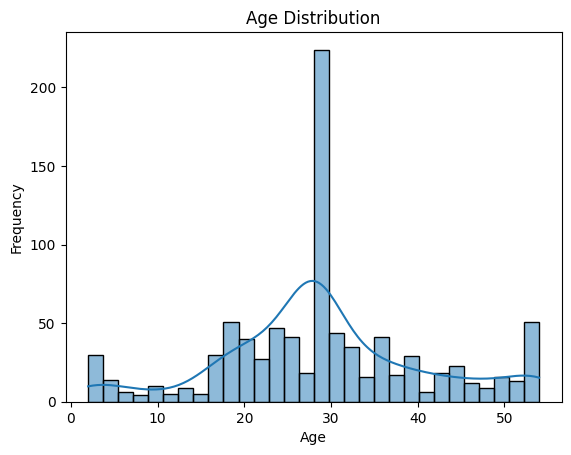

In [17]:
# TODO: Reload titanic_clean.csv into df_viz
# Then plot a histogram of the 'Age' column with a KDE curve
# Hint: sns.histplot(data=df_viz, x='Age', bins=30, kde=True)
# Add a title and axis labels
sns.histplot(data=df_viz, x='Age', bins=30, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

### 13.2 Count Plot — Survival Rate

**What it shows:** How many passengers survived vs did not survive.  
**What to look for:** Class imbalance — is the dataset balanced between 0 and 1?

> Class imbalance is important to identify before training a classifier.  
> If 90% of passengers did not survive, a model that always predicts 0 would be 90% accurate — but useless.


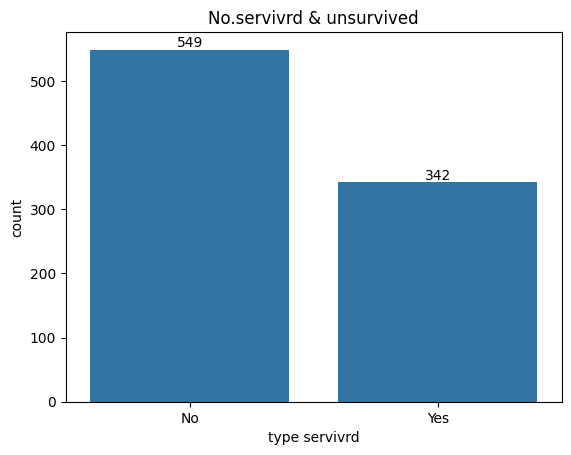

In [18]:
# TODO: Plot a count plot showing how many passengers survived vs did not
# Hint: sns.countplot(data=df_viz, x='Survived')
# Add count labels on top of each bar using ax.patches
sns.countplot(data=df_viz , x='Survived')
plt.title('No.servivrd & unsurvived')
plt.xlabel('type servivrd')
plt.ylabel('count')
plt.xticks([0, 1], ['No', 'Yes'])
plt.bar_label(plt.gca().containers[0])

plt.show()


### 13.3 Box Plot — Fare by Passenger Class

**What it shows:** Distribution of fare prices across the three passenger classes.  
**What to look for:** Differences in median fare, spread, and presence of outliers per class.

> Box plots show five statistics in one chart:  
> minimum, Q1, median, Q3, maximum — and points beyond the whiskers are outliers.


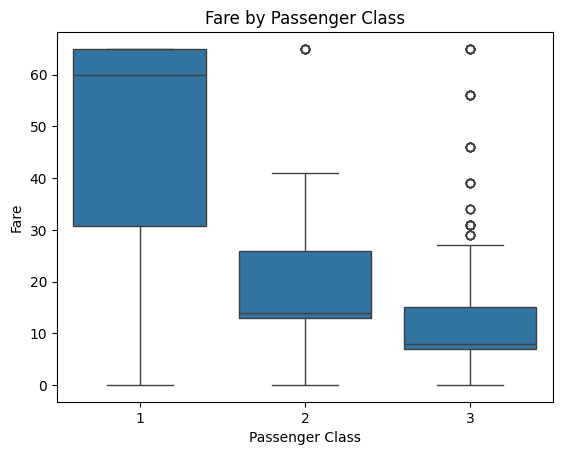

In [19]:
# TODO: Plot a box plot of 'Fare' grouped by 'Pclass'
# Hint: sns.boxplot(data=df_viz, x='Pclass', y='Fare')

sns.boxplot(data=df_viz, x='Pclass', y='Fare')
plt.title('Fare by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Fare')
plt.show()



### 13.4 Bar Plot — Survival Rate by Gender

**What it shows:** The proportion of survivors split by gender.  
**What to look for:** Was there a significant difference in survival between males and females?

> In the Titanic disaster, "women and children first" was the protocol during evacuation.  
> This chart will confirm whether that pattern is visible in the data.


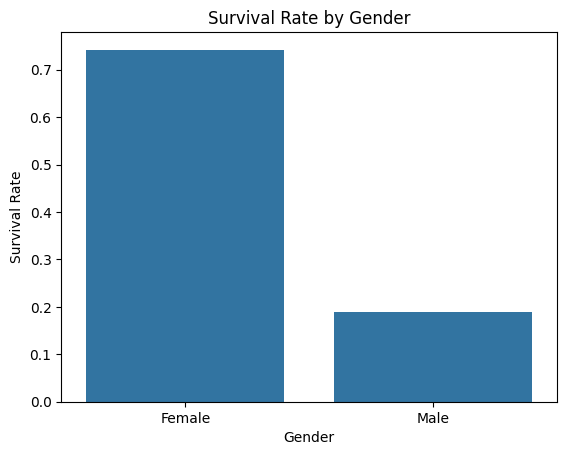

In [20]:
# TODO: Plot a bar chart showing survival RATE by gender (not count — the average of Survived per Sex)
# Hint: groupby('Sex')['Survived'].mean()
# Then use sns.barplot()

gr = df.groupby('Sex')['Survived'].mean()
type_gender = gr.index
result = gr.values
sns.barplot(x=type_gender, y=result)
plt.title('Survival Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Survival Rate')
plt.xticks([0, 1], ['Female', 'Male'])
plt.show()


### 13.5 Scatter Plot — Age vs Fare

**What it shows:** The relationship between passenger age and fare paid.  
**What to look for:** Is there a correlation? Do older or younger passengers tend to pay more?

> We color the points by `Survived` to see if age-fare combinations influenced survival.


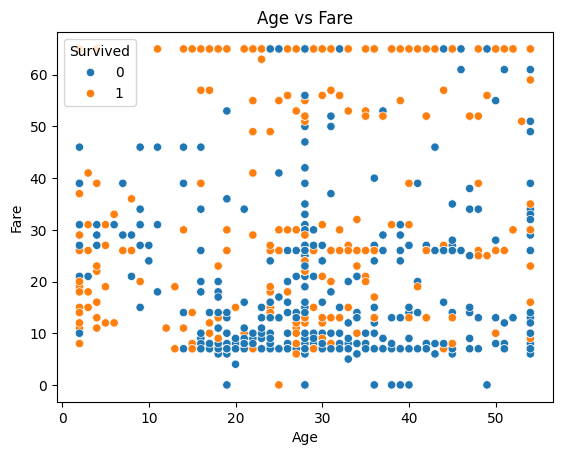

In [21]:
# TODO: Plot a scatter plot of Age vs Fare
# Color the points by 'Survived' using hue=
# Hint: sns.scatterplot(data=df_viz, x='Age', y='Fare', hue='Survived')
sns.scatterplot(data=df_viz, x='Age', y='Fare', hue='Survived')
plt.title('Age vs Fare')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()


### 13.6 Violin Plot — Age Distribution by Survival

**What it shows:** The full distribution shape of Age, split by whether the passenger survived.  
**What to look for:** Are there age ranges where survival was more common?

> A violin plot combines a box plot and a KDE (density) plot.  
> The wider the violin at a given value, the more passengers at that age.


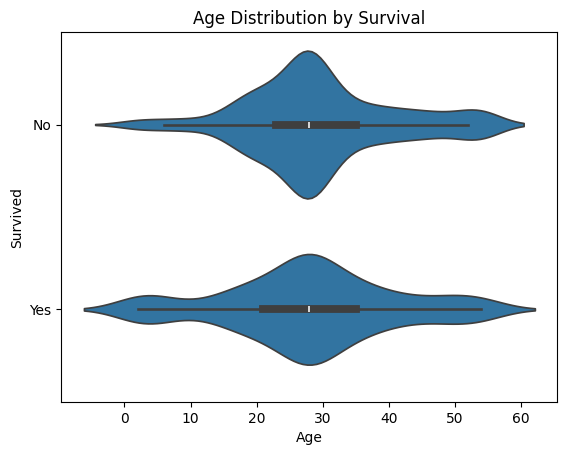

In [22]:
# TODO: Plot a violin plot of 'Age' split by survival outcome
# Hint: create a readable label column first (map 0/1 to text), then sns.violinplot()

df_viz['Survived'] = df_viz['Survived'].map({0: 'No', 1: 'Yes'})
sns.violinplot(data=df_viz, x='Age', y='Survived')
plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.ylabel('Survived')
plt.show()


### 13.7 Heatmap — Correlation Matrix

**What it shows:** The pairwise correlation between all numeric features.  
**What to look for:** Features strongly correlated with `Survived` are the most useful for modeling.  
Also look for features correlated with *each other* — this is called **multicollinearity**.

> Correlation values range from -1 to +1  
> +1 = perfect positive correlation  
> -1 = perfect negative correlation  
> 0  = no linear relationship


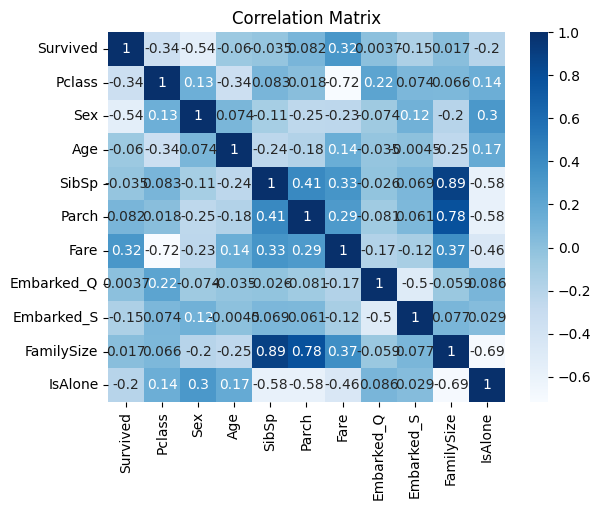

In [25]:
# TODO: Plot a correlation heatmap of all numeric columns
# Hint: df_viz.corr()  then  sns.heatmap(..., annot=True, cmap='Blues')
# Optional: mask the upper triangle using np.triu()
df_viz['Survived'] = df_viz['Survived'].map({'No':0 , 'Yes': 1})

corr = df_viz.corr()
sns.heatmap(corr, annot=True, cmap='Blues')
plt.title('Correlation Matrix')
plt.show()

### 13.8 Pie Chart — Passenger Class Distribution

**What it shows:** The proportion of passengers in each class.  
**What to look for:** Was the ship mostly third-class passengers?

> Use pie charts sparingly — they work well for 2–4 categories.  
> For more categories, a bar chart is easier to read.


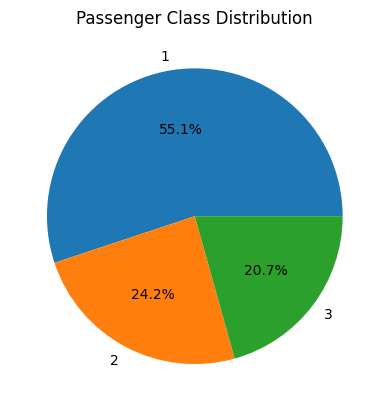

In [26]:
# TODO: Plot a pie chart showing the distribution of passengers across Pclass (1, 2, 3)
# Hint: value_counts(), then plt.pie() with labels and autopct='%1.1f%%'
plt.pie(df_viz['Pclass'].value_counts(), labels=[1, 2, 3], autopct='%1.1f%%')
plt.title('Passenger Class Distribution')
plt.show()


---
## Session Summary

In this session, we completed the full Data Preprocessing pipeline on the Titanic dataset.

| Step | What We Did |
|------|-------------|
| 1 | Imported all required libraries |
| 2 | Loaded the dataset from a public URL |
| 3 | Understood the data — shape, types, missing values |
| 4 | Handled missing values — median, mode, drop |
| 5 | Checked for duplicate records |
| 6 | Detected and treated outliers using IQR capping |
| 7 | Dropped columns with no predictive value |
| 8 | Encoded categorical features — Label Encoding and One-Hot Encoding |
| 9 | Created new features — FamilySize, IsAlone, AgeGroup |
| 10 | Scaled numeric features using StandardScaler |
| 11 | Assembled the final clean dataset |
| 12 | Exported to CSV — ready for modeling |
| 13 | Visualized 8 key charts to extract insights |

---

**The clean dataset `titanic_clean.csv` is now ready for Module 02 — Machine Learning.**


---

## Interview Questions — Test Your Understanding

Before you move to the next module, make sure you can answer these questions confidently.  
These are common entry-level interview questions on Data Preprocessing.

---

**1. What is the difference between filling missing values with the mean vs the median? When would you use each?**
ANs:
- The mean: This is considered a non-real data center and is affected by data containing an outlier. Therefore, we use it when the data distribution is normal and there is no outlier.

- The median is a true data center and is not affected by the outlier. It is used when the data distribution is skwed, and it can also be used when the data distribution is normal distribution.

---

**2. Why did we drop the `Cabin` column instead of trying to fill its missing values?**

-Because it contains a large number of null values, if we fill it with empty values, these values ​​will be unrealistic and therefore will give me unrealistic results.

---

**3. What is the IQR method, and how does it help detect outliers?**

-It is the difference between quartile 3 and quartile 1. We use it to determine the outlier values ​​by identifying the minimum and maximum limits.

---

**4. What is the difference between Label Encoding and One-Hot Encoding? Give an example of when you would use each.**

-Label encode:

Used for textual data to convert it to numbers, and is often used in target columns. Example: target column (sick/not sick). Here, the label encoder converts it to (0/1).

-One-hot encoder:

This is another method for converting text to numbers. However, this technique is used when the data is of type nomanial. It sets the value to 1 and the rest to 0. For example: the names of countries (Gaza - Egypt - Jordan). They are converted according to the value in the data row; the value is converted to 1 and the rest to 0.

---

**5. Why is it important to fit a scaler (like StandardScaler) only on the training data, not the full dataset?**

-The fit is performed only on the training data because techniques like standard scalers examine the data to extract the mean and standard division. If we apply standard scalers to all the data, the model will save the data, which will cause data leakage.

---

**6. What does it mean for a dataset to have "data leakage"? Give an example from this notebook.**

-The fit is performed only on the training data because techniques like standard scalers examine the data to extract the mean and standard division. If we apply standard scalers to all the data, the model will save the data, which will cause data leakage.

-Applying the standard scaler to all data before splitting it for training and testing

---

**7. Why do we use `drop_first=True` when applying One-Hot Encoding?**

-To avoid multicolunirety in the data

---

**8. What is the difference between removing an outlier and capping (Winsorizing) it? Which one did we use, and why?**

-Outlier Removal:
Records containing outliers are completely removed from the dataset, thus reducing the sample size.

-Winsorizing:
Records are not deleted. Instead, outliers are replaced with a specific threshold value (such as the upper or lower limit of acceptable data), thereby preserving all data while minimizing the impact of outliers.

-What did we use and why?

We used winsorizing because we wanted to preserve all records and avoid losing any important data, while simultaneously reducing the negative impact of outliers on model performance and statistical analysis.--

---

**9. What is Feature Engineering, and why did we create `FamilySize` and `IsAlone` instead of just using `SibSp` and `Parch` directly?**

-Feature engineering:

This is the process of deleting unnecessary columns or creating new columns from existing data to help the model achieve optimal performance.

-We created the FamilySize and IsAlone columns because they provide clearer information:

Family size: Represents the total number of family members accompanying the passenger.

IsAlone: ​​Indicates whether the passenger is traveling alone or not.
---

**10. Why do we visualize the data using charts like box plots and heatmaps instead of just looking at the raw numbers?**

-Because graphs make understanding data and discovering patterns easier and faster than looking at raw numbers alone.

Box plots help in identifying outliers and understanding data distribution and spread.

Heatmaps help visually and clearly show the relationships and correlations between variables.

---

> **Tip:** Try answering from memory first, then scroll back through the notebook to check your answer.  
> If you can explain *why* a step was needed — not just *what* it did — you understood the lesson.

---
*DOT PY · Data Science & AI Program · Module 01 · 2026*
